In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from IPython.display import display, HTML

In [2]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/2025-Y2-S1-MLB-B8G1-03_AIML_Evaluation_2/Data/student_depression_balanced.csv")

In [5]:
# Separate features and target
X = df.drop("Depression", axis=1)
y = df["Depression"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")
print("-" * 70)

Training set: (25387, 10), Testing set: (6347, 10)
----------------------------------------------------------------------



=== Training: Model 1 (Baseline) ===
Accuracy : 0.7758 | Precision: 0.7682 | Recall: 0.7898 | F1-Score: 0.7789 | AUC: 0.8499
Confusion Matrix:
[[2418  756]
 [ 667 2506]]


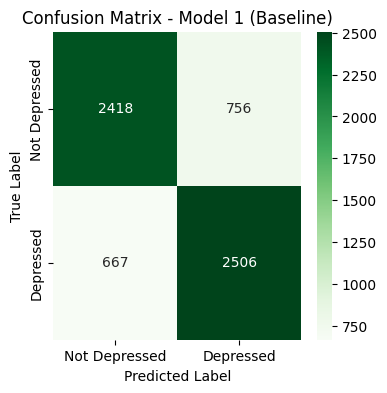


=== Training: Model 2 (High Recall Tune) ===
Accuracy : 0.7905 | Precision: 0.7655 | Recall: 0.8374 | F1-Score: 0.7998 | AUC: 0.8565
Confusion Matrix:
[[2360  814]
 [ 516 2657]]


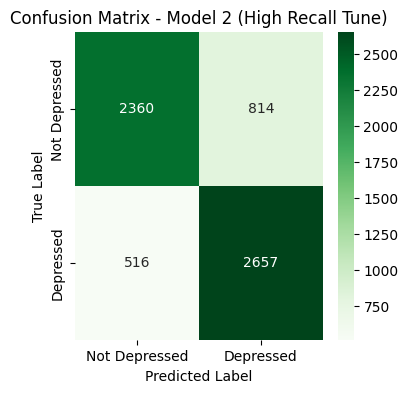


=== Training: Model 3 (High F1/AUC Tune) ===
Accuracy : 0.7953 | Precision: 0.7721 | Recall: 0.8380 | F1-Score: 0.8037 | AUC: 0.8638
Confusion Matrix:
[[2389  785]
 [ 514 2659]]


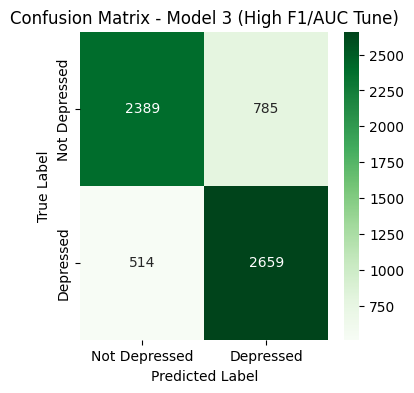

In [6]:
# PART 1: TRAIN AND EVALUATE MODELS
models_params = {
    "Model 1 (Baseline)": {'n_estimators': 100, 'criterion': 'gini'},
    "Model 2 (High Recall Tune)": {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'},
    "Model 3 (High F1/AUC Tune)": {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 2, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}
}

results_summary = {}

for name, params in models_params.items():
    print(f"\n=== Training: {name} ===")

    # Initialize and train model
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # Print metrics horizontally
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f} | AUC: {auc_score:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Save results
    results_summary[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc_score,
        'Confusion_Matrix': cm,
        'y_pred_proba': y_pred_proba
    }

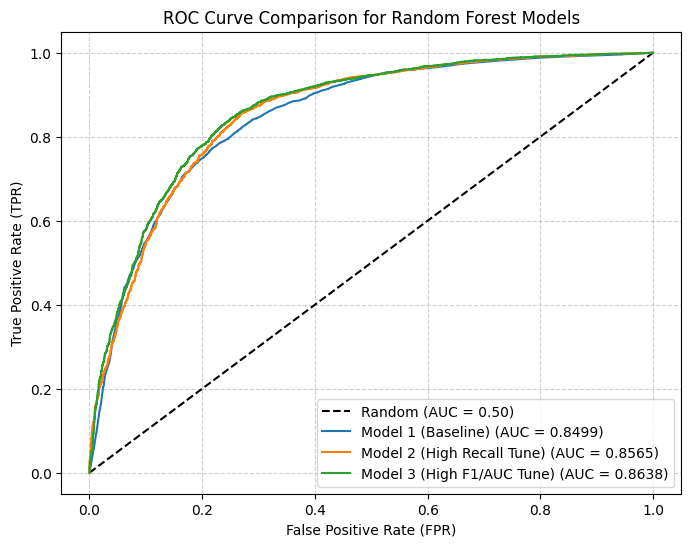

In [ ]:
# PART 2: ROC CURVE COMPARISON

plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1],'k--', label='Random (AUC = 0.50)')
for name, res in results_summary.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.title('ROC Curve Comparison for Random Forest Models')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# PART 3: K-FOLD CROSS-VALIDATION ON BEST MODEL
best_model_name = max(results_summary, key=lambda x: results_summary[x]['AUC'])
best_model = RandomForestClassifier(**models_params[best_model_name], random_state=42)

print(f"\nK-FOLD CROSS-VALIDATION (5-Fold) on Best Model: {best_model_name}")
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'recall', 'roc_auc']

for score_type in scoring:
    cv_results = cross_val_score(best_model, X_full, y_full, cv=kfold, scoring=score_type, n_jobs=-1)
    print(f"{score_type.upper():<8}: Mean={cv_results.mean():.4f} | Std={cv_results.std():.4f}")


K-FOLD CROSS-VALIDATION (5-Fold) on Best Model: Model 3 (High F1/AUC Tune)
ACCURACY: Mean=0.7885 | Std=0.0034
F1      : Mean=0.7967 | Std=0.0034
RECALL  : Mean=0.8287 | Std=0.0046
ROC_AUC : Mean=0.8610 | Std=0.0043


In [ ]:
# PART 4: FINAL SUMMARY

print("\n=== Final Model Comparison ===")
for name, res in results_summary.items():
    print(f"{name:<25}: Accuracy={res['Accuracy']:.4f} | Precision={res['Precision']:.4f} | Recall={res['Recall']:.4f} | F1={res['F1-Score']:.4f} | AUC={res['AUC']:.4f}")

print(f"\nBest Model: {best_model_name} with highest AUC={results_summary[best_model_name]['AUC']:.4f}")


=== Final Model Comparison ===
Model 1 (Baseline)       : Accuracy=0.7758 | Precision=0.7682 | Recall=0.7898 | F1=0.7789 | AUC=0.8499
Model 2 (High Recall Tune): Accuracy=0.7905 | Precision=0.7655 | Recall=0.8374 | F1=0.7998 | AUC=0.8565
Model 3 (High F1/AUC Tune): Accuracy=0.7953 | Precision=0.7721 | Recall=0.8380 | F1=0.8037 | AUC=0.8638

Best Model: Model 3 (High F1/AUC Tune) with highest AUC=0.8638


In [ ]:
import pickle

# Save the trained Random Forest model as a .pkl file
with open("/content/drive/MyDrive/AIML_Evaluation/random_forest_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as random_forest_model.pkl")


Model saved successfully as random_forest_model.pkl
